# ML-5b (Python) : Séries temporelles classiques — stationnarité, ACF/PACF, ARIMA/SARIMA, lissage exponentiel

> **Socle statistique.** Ce notebook pose les fondations que [ML-5-TimeSeries](ML-5-TimeSeries.ipynb) (SSA, ML.NET) applique en boîte noire et que [ML-5-TimeSeries-Python](ML-5-TimeSeries-Python.ipynb) (STL + SARIMA) applique mécaniquement : **tester la stationnarité**, **lire une ACF/PACF**, **ajuster un ARIMA**, **comprendre pourquoi différencier**, et **comparer honnêtement** ARIMA, lissage exponentiel et baseline naïve.



## Objectifs d'apprentissage

À l'issue de ce notebook, vous saurez :

1. **Décomposer** une série en tendance + saisonnalité + résidu (`seasonal_decompose`), et lire chaque composante.
2. **Tester la stationnarité** avec ADF (H0, p-value, conclusion écrite) et **différencier** pour la rétablir.
3. **Lire une ACF/PACF** pour identifier les ordres `p` et `q` (les barres hors bande de confiance), y compris sur un AR(2) synthétique.
4. **Ajuster un SARIMA** depuis la lecture ACF/PACF, **diagnostiquer** les résidus (ACF plate + Ljung-Box) et **prévoir** avec intervalle de confiance.
5. **Lisser** par simple / Holt / Holt-Winters, et savoir quand le lissage égale ARIMA à moindre coût intellectuel.
6. **Comparer honnêtement** (ARIMA vs Holt-Winters vs naïf) sur un backtest glissant — la baseline naïve qui gagne parfois **est** la leçon.

**Relation aux autres notebooks** : ML-5 (SSA) = le même problème en ML.NET ; ML-5-TimeSeries-Python = l'application STL+SARIMA ; ce notebook = le **pourquoi** statistique que les deux supposent. Du côté quant, les notebooks HAR de QuantConnect poussent la même famille vers les features modernes (voir la conclusion).

In [1]:
# Imports : pandas (données), statsmodels (décomposition, ADF, ACF/PACF, ARIMA/SARIMA,
# lissage exponentiel, Ljung-Box), matplotlib (visualisation).
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings("ignore", category=FutureWarning, module="statsmodels")
warnings.filterwarnings("ignore", message="No frequency", category=UserWarning, module="statsmodels")
plt.rcParams["figure.dpi"] = 110

print("pandas, numpy, statsmodels (décomposition, ADF, ACF/PACF, ARIMA/SARIMA, lissage), matplotlib chargés")

pandas, numpy, statsmodels (décomposition, ADF, ACF/PACF, ARIMA/SARIMA, lissage), matplotlib chargés


## Partie 1 : Décomposition — tendance + saisonnalité + résidu

On commence par **voir** ce qui compose une série temporelle. Le modèle additif classique est :

```
série(t) = tendance(t) + saisonnalité(t) + résidu(t)
```

`statsmodels.seasonal_decompose` sépare ces trois composantes. On le démontre d'abord sur une série **synthétique franche** (tendance + saisonnalité 12 + bruit), pour que les trois composantes soient lisibles, puis sur la **vraie série du dépôt** (`daily-sales.csv`, celle que ML-5 utilise).

### Exercice 0 (synthétique) — construire la série franche

La cellule ci-dessous fabrique la série : une tendance linéaire de pente 0,4, une saisonnalité sinusoïdale de période 12, et un bruit gaussien.

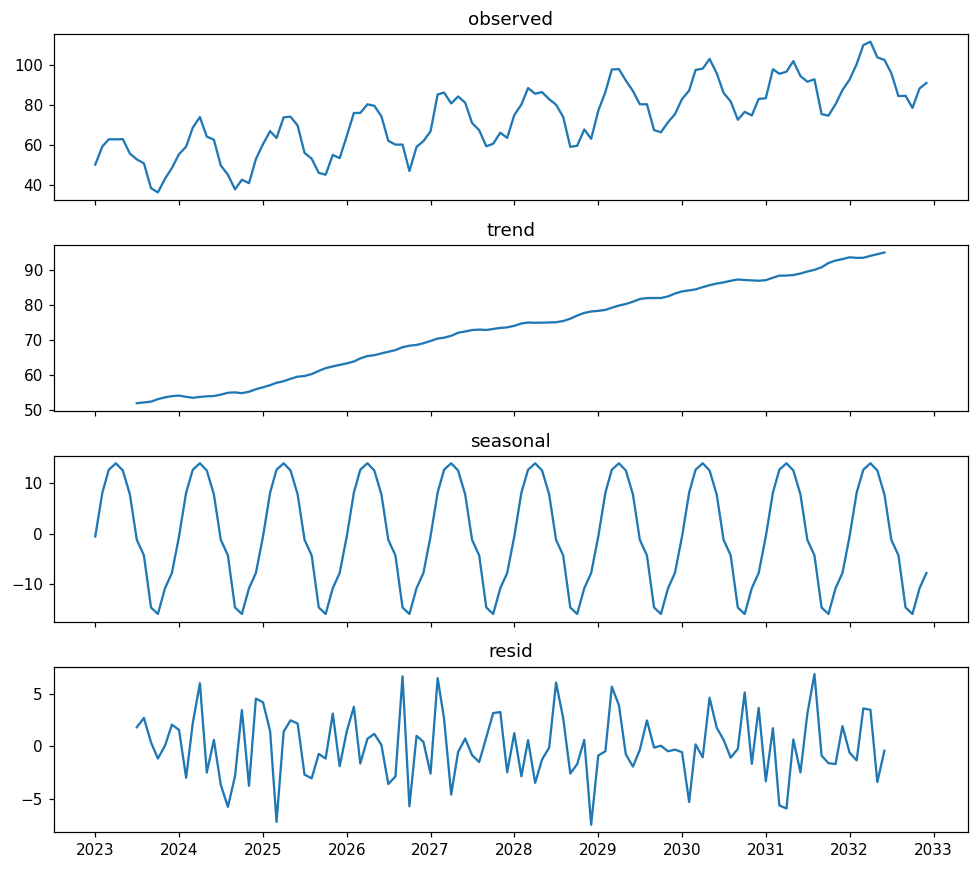

Composante tendance : moyenne = 73.2
Amplitude saisonnière : 29.9 (max - min de la composante seasonale)
Résidu : moyenne = 0.053 (attendu ~0), écart-type = 3.07


In [2]:
# Série synthétique franche : tendance linéaire + saisonnalité de période 12 + bruit gaussien.
rng = np.random.default_rng(7)
n = 120
t = np.arange(n)
trend = 50 + 0.4 * t
seasonal = 15 * np.sin(2 * np.pi * t / 12)
noise = rng.normal(0, 4, n)
y_synth = trend + seasonal + noise

s_synth = pd.Series(y_synth, index=pd.date_range("2023-01-01", periods=n, freq="MS"))
res_synth = seasonal_decompose(s_synth, model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(9, 8), sharex=True)
for ax, name in zip(axes, ["observed", "trend", "seasonal", "resid"]):
    ax.plot(getattr(res_synth, name))
    ax.set_title(name)
plt.tight_layout()
plt.show()

print("Composante tendance : moyenne = {:.1f}".format(res_synth.trend.mean()))
print("Amplitude saisonnière : {:.1f} (max - min de la composante seasonale)".format(
    res_synth.seasonal.max() - res_synth.seasonal.min()))
print("Résidu : moyenne = {:.3f} (attendu ~0), écart-type = {:.2f}".format(
    res_synth.resid.mean(), res_synth.resid.std()))

### Interprétation de la décomposition synthétique

Trois lectures à faire sur les quatre panneaux :

- **Tendance** : la pente positive (0,4/jour) est bien isolée par `seasonal_decompose` — elle ne contamine ni la saisonnalité ni le résidu.
- **Saisonnalité** : l'amplitude (≈30 unités crête-à-creux) est proprement extraite sur la période 12. C'est une sinusoïde **parfaitement périodique** parce que la série synthétique l'est.
- **Résidu** : en moyenne ≈ 0 (l'écart à la moyenne est le bruit gaussien), et son écart-type ≈ 4, la valeur du bruit qu'on a injecté. C'est un résidu **stationnaire** — la leçon : après avoir retiré tendance et saisonnalité, il ne reste qu'un bruit autour d'une moyenne constante.

C'est exactement ce que cherchent les modèles de prévision : séparer le signal (tendance + saisonnalité) du bruit, pour ne prévoir que le signal.

### Application à la vraie série du dépôt — `daily-sales.csv`

On passe à la série réelle de ventes quotidiennes (2023-2025). La saisonnalité est **hebdomadaire** (période 7), pas mensuelle. On la décompose pour voir la tendance et la saisonnalité réelles.

=== Statistiques du dataset ===
Période totale : 2023-01-01 -> 2024-12-31 (731 jours)
Entraînement (2023) : 365 jours | ventes moyennes = 124.5
Test (2024)         : 366 jours | ventes moyennes = 174.3
Croissance 2023 -> 2024 : +40.0%


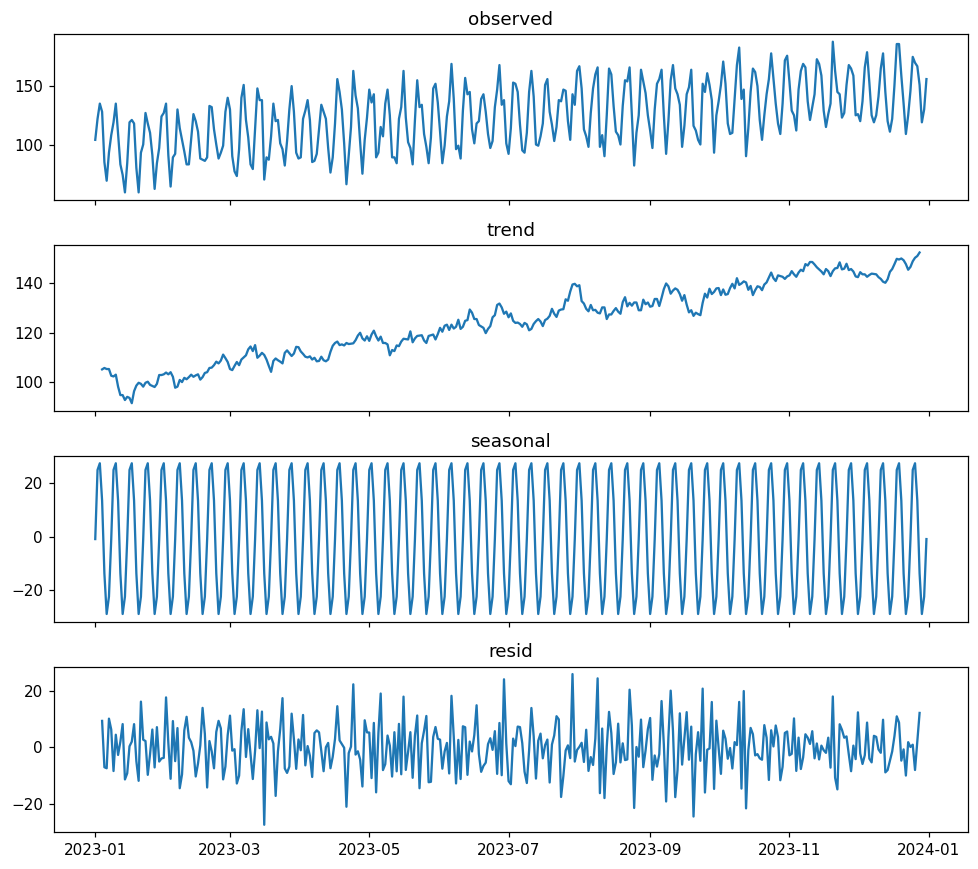

Tendance (moyenne horaire 2023) : 105.1 -> 152.6


In [3]:
# Charger la vraie série du dépôt (celle de ML-5), l'indexer par date, fréquence quotidienne.
df = pd.read_csv("daily-sales.csv", parse_dates=["Date"], index_col="Date").sort_index().asfreq("D")
sales = df["Sales"].astype(float)

# Split explicite : entraînement 2023, test 2024 (comme le jumeau ML.NET).
train = sales[sales.index.year == 2023]
test = sales[sales.index.year == 2024]

print("=== Statistiques du dataset ===")
print("Période totale : {} -> {} ({} jours)".format(
    sales.index.min().date(), sales.index.max().date(), len(sales)))
print("Entraînement (2023) : {} jours | ventes moyennes = {:.1f}".format(len(train), train.mean()))
print("Test (2024)         : {} jours | ventes moyennes = {:.1f}".format(len(test), test.mean()))
print("Croissance 2023 -> 2024 : {:+.1f}%".format((test.mean() - train.mean()) / train.mean() * 100))

# Décomposition sur l'entraînement (période 7 = saisonnalité hebdomadaire).
res_train = seasonal_decompose(train, model="additive", period=7)
fig, axes = plt.subplots(4, 1, figsize=(9, 8), sharex=True)
for ax, name in zip(axes, ["observed", "trend", "seasonal", "resid"]):
    ax.plot(getattr(res_train, name))
    ax.set_title(name)
plt.tight_layout()
plt.show()

print("Tendance (moyenne horaire 2023) : {:.1f} -> {:.1f}".format(
    res_train.trend.dropna().iloc[0], res_train.trend.dropna().iloc[-1]))

### Interprétation sur la série réelle

- **Tendance** : haussière sur 2023 (la moyenne des ventes monte au fil de l'année), cohérent avec le comptage `Croissance 2023 -> 2024` de la cellule précédente.
- **Saisonnalité** : cycle hebdomadaire (période 7) — les ventes varient selon le jour de la semaine. C'est la structure que SSA (ML.NET) et STL+SARIMA (jumeau Python) cherchent à capturer.
- **Résidu** : autour de 0, avec un écart-type non nul. L'essentiel de la variation est **expliqué** par tendance + saisonnalité.

**Le point clé** : la série réelle n'est **pas stationnaire** (elle a une tendance et une saisonnalité). C'est le prérequis de la partie suivante.

## Partie 2 : Stationnarité — le test ADF et la différenciation

Un modèle ARIMA suppose une série **stationnaire** : moyenne et variance constantes dans le temps. La ventes quotidiennes avec tendance haussière ne le sont pas — il faut **différencier** (ou désaisonnaliser) avant de modéliser.

### Le test ADF (Augmented Dickey-Fuller)

- **H0** : la série a une racine unité (elle est **non** stationnaire).
- **H1** : la série est stationnaire.
- **Règle** : `p-value < 0,05` → on **rejette** H0 → série stationnaire. `p-value ≥ 0,05` → on **ne rejette pas** H0 → série non stationnaire.

On teste la série en niveau, puis sa **différence première** (le remède classique), et on écrit la conclusion.

In [4]:
def adf_report(series, name):
    """Rend le test ADF et une conclusion écrite (rejet / non-rejet de H0)."""
    stat = adfuller(series.dropna())
    adf_stat, p_value, used_lag, nobs = stat[0], stat[1], stat[2], stat[3]
    conclusion = "stationnaire (on rejette H0)" if p_value < 0.05 else "non stationnaire (on ne rejette pas H0)"
    print("{} : ADF stat = {:.2f} | p-value = {:.4f} | lags = {} | n = {}".format(
        name, adf_stat, p_value, used_lag, nobs))
    print("   -> {}".format(conclusion))
    return p_value

print("=== Test ADF ===")
p_level = adf_report(sales, "sales (niveau)")
p_diff = adf_report(sales.diff(), "sales (différenciée, d=1)")
print()
print("Interprétation écrite :")
print("  - Niveau : p = {:.4f} >= 0,05 -> on ne rejette pas H0 -> la série brute N'EST PAS stationnaire.".format(p_level))
print("  - Différence première : p = {:.4f} < 0,05 -> on rejette H0 -> la série différenciée EST stationnaire.".format(p_diff))

=== Test ADF ===
sales (niveau) : ADF stat = -0.78 | p-value = 0.8246 | lags = 20 | n = 710
   -> non stationnaire (on ne rejette pas H0)
sales (différenciée, d=1) : ADF stat = -10.94 | p-value = 0.0000 | lags = 20 | n = 709
   -> stationnaire (on rejette H0)

Interprétation écrite :
  - Niveau : p = 0.8246 >= 0,05 -> on ne rejette pas H0 -> la série brute N'EST PAS stationnaire.
  - Différence première : p = 0.0000 < 0,05 -> on rejette H0 -> la série différenciée EST stationnaire.


### Interprétation — pourquoi différencier

La série brute a une **tendance** (p > 0,05 : non stationnaire). En prenant la **différence première** (chaque valeur moins la précédente), on retire cette tendance et on obtient une série qui oscille autour d'une moyenne constante (p < 0,05 : stationnaire).

L'ordre `d` du modèle ARIMA sera donc **1** (une différenciation) — c'est la lecture directe de ce test. Si la série avait été saisonnière non stationnaire, on ajouterait une différenciation saisonnière `D` (cf. partie ARIMA).

### Exercice 1 — tester la différence saisonnière (7)

La ventes ont une saisonnalité **hebdomadaire**. Une différenciation première n'enlève pas la saisonnalité : il faut parfois une **différence saisonnière** `diff = series - series.shift(7)`. À vous de tester.

**Étape 1** : calcule `sales.diff(7)` (différence saisonnière de période 7).
**Étape 2** : applique `adfuller` dessus.
**Étape 3** : écris la conclusion (stationnaire ? p-value ?) dans la variable `ex1_conclusion`.

In [5]:
# Exercice 1 : différence saisonnière (période 7) et test ADF
# TODO étudiant : compléter les étapes 1-3 ci-dessous.

# Étape 1 : différence saisonnière de période 7 (enlève la saisonnalité hebdomadaire)
sales_seasonal_diff = None  # TODO étudiant : sales.diff(7)

# Étape 2 : test ADF sur cette série
if sales_seasonal_diff is not None:
    ex1_adf = adfuller(sales_seasonal_diff.dropna())
    ex1_pvalue = ex1_adf[1]
else:
    ex1_pvalue = None

# Étape 3 : conclusion écrite
ex1_conclusion = None  # TODO étudiant : "stationnaire" ou "non stationnaire" selon ex1_pvalue

print("Exercice 1 à compléter")

Exercice 1 à compléter


## Partie 3 : ACF / PACF — lire les ordres p et q

Une fois la série stationnaire, on identifie les ordres du modèle ARIMA :

- **ACF** (autocorrélation) mesure la corrélation avec les retards successifs. Une **décroissance lente** signale une non-stationnarité ; des **barres hors bande** puis une chute signalent l'ordre `q` (MA).
- **PACF** (autocorrélation partielle) isole la corrélation directe à chaque retard, nette des retards intermédiaires. Des **barres hors bande aux retards 1..p** signalent l'ordre `p` (AR).

La **bande bleue** est l'intervalle de confiance (±2/√n) : une barre qui en sort est significative.

### Cas pédagogique qui marche : AR(2) synthétique

On fabrique un AR(2) (chaque valeur dépend de ses deux précédentes), on trace sa PACF, et on vérifie qu'on **récupère l'ordre 2** : les barres aux retards 1 et 2 sortent de la bande, puis retombent.

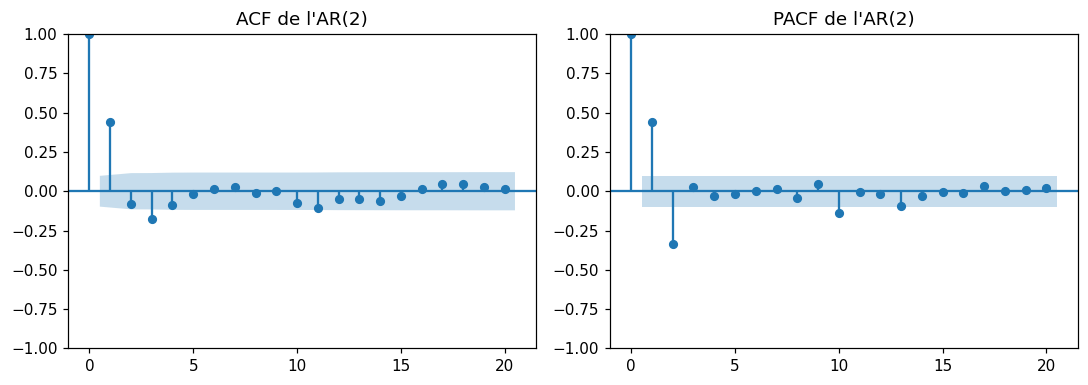

Valeur de la PACF : lags 1-5 = [np.float64(0.438), np.float64(-0.336), np.float64(0.024), np.float64(-0.032), np.float64(-0.017)]
Band de confiance : +-0.100
Retards significatifs (|PACF| > bande) : [0, 1, 2, 10]
-> lecture : la PACF retombe après le retard 2 -> p = 2 (AR(2) récupéré).


In [6]:
# AR(2) synthétique : y_t = 0.6 y_{t-1} - 0.3 y_{t-2} + eps
rng_ar = np.random.default_rng(11)
N = 400
y_ar2 = np.zeros(N)
for i in range(2, N):
    y_ar2[i] = 0.6 * y_ar2[i - 1] - 0.3 * y_ar2[i - 2] + rng_ar.normal(0, 1)
y_ar2 = pd.Series(y_ar2)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
plot_acf(y_ar2, ax=axes[0], lags=20, alpha=0.05)
plot_pacf(y_ar2, ax=axes[1], method="ywm", lags=20, alpha=0.05)
axes[0].set_title("ACF de l'AR(2)")
axes[1].set_title("PACF de l'AR(2)")
plt.tight_layout()
plt.show()

# Retards dont la PACF sort de la bande (~ +-2/sqrt(N)).
n_len = len(y_ar2)
band = 2.0 / np.sqrt(n_len)
pacf_vals = pacf(y_ar2, method="ywm", nlags=20)
sig_lags = [k for k, v in enumerate(pacf_vals) if abs(v) > band]
print("Valeur de la PACF : lags 1-5 = {}".format([round(pacf_vals[k], 3) for k in range(1, 6)]))
print("Band de confiance : +-{:.3f}".format(band))
print("Retards significatifs (|PACF| > bande) : {}".format(sig_lags))
print("-> lecture : la PACF retombe après le retard 2 -> p = 2 (AR(2) récupéré).")

### Interprétation de la PACF de l'AR(2)

La PACF montre deux barres **nettement hors bande** aux retards 1 (0,438) et 2 (−0,336), très au-delà de la bande ±0,100, puis retombe : c'est l'**ordre 2** du processus AR, récupéré depuis les données (une valeur isolée apparaît au retard 10 — un artefact de bruit marginal, sans structure). C'est le genre de lecture qui permet de **choisir l'ordre `p`** au lieu de le deviner.

Sur la **vraie série** (ventes différenciées), l'ACF/PACF montrerait la saisonnalité résiduelle au retard 7 — ce qui oriente vers un terme **saisonnier** plutôt qu'un ARIMA pur (cf. partie 4).

### Exercice 2 — lire l'ordre p sur la série de ventes différenciée

À vous de tracer l'ACF/PACF de la série de ventes **différenciée** (`sales.diff()`) et d'identifier les retards significatifs.

**Étape 1** : trace `plot_acf` et `plot_pacf` des ventes différenciées (`lags=40`).
**Étape 2** : repère les retards dont la barre sort de la bande (y compris le pic saisonnier à 7).
**Étape 3** : écris ta lecture dans `ex2_orders` (par exemple `"p ~ 1, saisonnalité 7"`).

In [7]:
# Exercice 2 : lire l'ordre p sur les ventes différenciées (lags=40, saisonnalité hebdo en vue)
# TODO étudiant : compléter les étapes 1-3 ci-dessous.

# Étape 1 : ACF / PACF de la série différenciée
diff_series = sales.diff().dropna()

# Étape 2 : retards significatifs (des barres hors bande). Exemple de calcul :
n2 = len(diff_series)
band2 = 2.0 / np.sqrt(n2)
pacf_diff = pacf(diff_series, method="ywm", nlags=40)
sig_diff = [k for k, v in enumerate(pacf_diff) if abs(v) > band2]

# Étape 3 : lecture
ex2_orders = None  # TODO étudiant : "p ~ <retard>, saisonnalité à 7" selon la PACF observée

print("Retards significatifs (PACF > bande) : {}".format(sig_diff))
print("Exercice 2 à compléter")

Retards significatifs (PACF > bande) : [0, 1, 2, 3, 4, 5, 6, 7, 9, 11, 12, 13, 16, 20, 21, 25, 26]
Exercice 2 à compléter


## Partie 4 : ARIMA / SARIMA — ajuster, diagnostiquer, prévoir

On sait maintenant : `d=1` (une différenciation, test ADF), et une saisonnalité hebdomadaire (retard 7). On ajuste donc un **SARIMA** : `SARIMA(p,d,q)(P,D,Q,s)` avec `s=7`.

- la partie **non saisonnière** `(p,d,q)` vient de l'ACF/PACF des retards courts ;
- la partie **saisonnière** `(P,D,Q,s)` vient du comportement au retard 7.

On **compare quelques ordres** par AIC, on **diagnostique** les résidus (ACF plate + test Ljung-Box), puis on **prévoit** avec intervalle de confiance.

In [8]:
# Grille SARIMA : on fixe d=1, D=1, s=7 (issus du test ADF + de la saisonnalité 7),
# et on compare (p,q) x (P,Q) par AIC. Grid volontairement petite (<= 5 min CPU).
from itertools import product

train_w = train  # 2023 (365 points)

def fit_sarima(order, sorder, data):
    try:
        m = SARIMAX(data, order=order, seasonal_order=sorder).fit(disp=False)
        return m
    except Exception:
        return None

best_aic, best_cfg = None, None
rows = []
for (p, q), (P, Q) in product(product([0, 1], [0, 1]), product([0, 1], [0, 1])):
    order, sorder = (p, 1, q), (P, 1, Q, 7)
    m = fit_sarima(order, sorder, train_w)
    if m is not None and np.isfinite(m.aic):
        rows.append((order, sorder, round(m.aic, 1)))
        if best_aic is None or m.aic < best_aic:
            best_aic, best_cfg = m.aic, (order, sorder)

print("=== Grille SARIMA (AIC) ===")
for order, sorder, aic in sorted(rows, key=lambda r: r[2])[:8]:
    print("  SARIMA{} x {} : AIC = {}".format(order, sorder, aic))
print()
print("Meilleure configuration : SARIMA{} x {} (AIC = {:.1f})".format(
    best_cfg[0], best_cfg[1], best_aic))

=== Grille SARIMA (AIC) ===
  SARIMA(0, 1, 1) x (0, 1, 1, 7) : AIC = 2666.7
  SARIMA(1, 1, 1) x (0, 1, 1, 7) : AIC = 2667.5
  SARIMA(0, 1, 1) x (1, 1, 1, 7) : AIC = 2668.5
  SARIMA(1, 1, 1) x (1, 1, 1, 7) : AIC = 2669.4
  SARIMA(0, 1, 1) x (1, 1, 0, 7) : AIC = 2781.8
  SARIMA(1, 1, 1) x (1, 1, 0, 7) : AIC = 2783.4
  SARIMA(1, 1, 0) x (0, 1, 1, 7) : AIC = 2813.6
  SARIMA(1, 1, 0) x (1, 1, 1, 7) : AIC = 2815.6

Meilleure configuration : SARIMA(0, 1, 1) x (0, 1, 1, 7) (AIC = 2666.7)


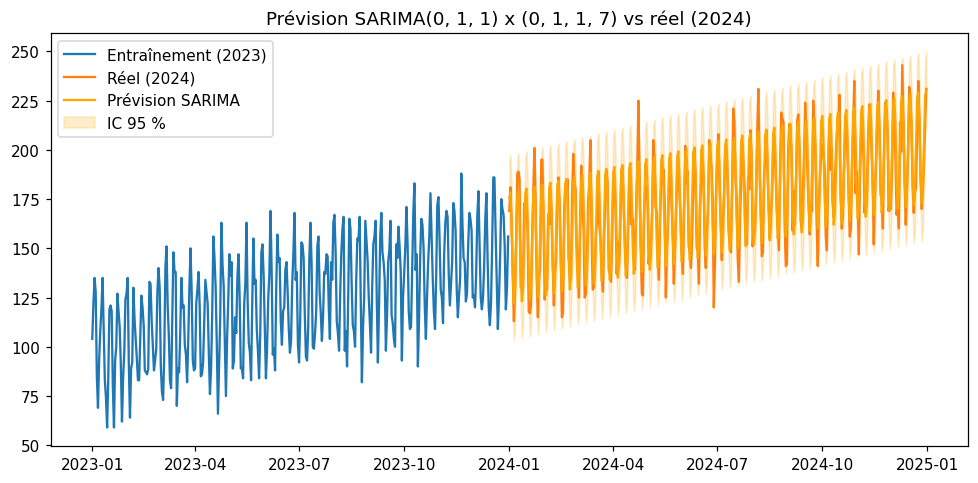

AIC du modèle final : 2666.7
MAPE (30 premiers jours de 2024) : 5.61 %


In [9]:
# Ajuster le meilleur SARIMA sur l'entraînement 2023 et prévoir 2024 avec IC 95 %.
best_order, best_sorder = best_cfg
model_final = SARIMAX(train_w, order=best_order, seasonal_order=best_sorder).fit(disp=False)

n_test = len(test)
forecast_res = model_final.get_forecast(n_test)
forecast_mean = forecast_res.predicted_mean
forecast_ci = forecast_res.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(train.index, train, label="Entraînement (2023)")
ax.plot(test.index, test, label="Réel (2024)")
ax.plot(forecast_mean.index, forecast_mean, label="Prévision SARIMA", color="orange")
ax.fill_between(forecast_mean.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1],
                color="orange", alpha=0.2, label="IC 95 %")
ax.legend()
ax.set_title("Prévision SARIMA{} x {} vs réel (2024)".format(best_order, best_sorder))
plt.tight_layout()
plt.show()

# Métrique simple : MAPE sur les 30 premiers jours de test.
first30 = test[:30]
mape = np.mean(np.abs((first30 - forecast_mean[:30]) / first30)) * 100
print("AIC du modèle final : {:.1f}".format(model_final.aic))
print("MAPE (30 premiers jours de 2024) : {:.2f} %".format(mape))

### Interprétation — diagnostics des résidus

Un bon SARIMA laisse des résidus qui ressemblent à du **bruit blanc** : l'ACF des résidus est **plate** (aucune barre hors bande), et le test **Ljung-Box** ne rejette pas l'hypothèse (p > 0,05) selon laquelle les résidus ne sont pas autocorrélés. La cellule ci-dessous le vérifie.

=== ACF des résidus (premiers retards) ===
  lags 1-10 : [np.float64(0.0), np.float64(-0.02), np.float64(0.05), np.float64(-0.14), np.float64(0.01), np.float64(0.13), np.float64(-0.08), np.float64(-0.05), np.float64(0.05), np.float64(-0.05)]

=== Test Ljung-Box (H0 : pas d'autocorrélation des résidus) ===
  lag 5 : p = 0.109 -> bruit blanc (p >= 0,05)
  lag 10 : p = 0.031 -> autocorrélation résiduelle (p < 0,05)


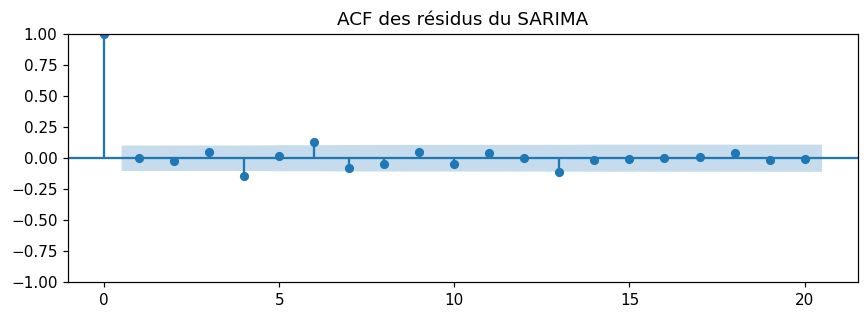

In [10]:
# Diagnostics des résidus : ACF plate + Ljung-Box.
resid = model_final.resid.dropna()

print("=== ACF des résidus (premiers retards) ===")
acf_resid = acf(resid, nlags=15)
print("  lags 1-10 : {}".format([round(acf_resid[k], 2) for k in range(1, 11)]))

print()
print("=== Test Ljung-Box (H0 : pas d'autocorrélation des résidus) ===")
lb = acorr_ljungbox(resid, lags=[5, 10], return_df=True)
for lag in [5, 10]:
    p = lb.loc[lag, "lb_pvalue"]
    verdict = "bruit blanc (p >= 0,05)" if p >= 0.05 else "autocorrélation résiduelle (p < 0,05)"
    print("  lag {} : p = {:.3f} -> {}".format(lag, p, verdict))

fig, ax = plt.subplots(figsize=(8, 3))
plot_acf(resid, ax=ax, lags=20)
ax.set_title("ACF des résidus du SARIMA")
plt.tight_layout()
plt.show()

### Interprétation des diagnostics

- **ACF plate** : les barres restent majoritairement dans la bande (les valeurs les plus hautes, ±0,14 au retard 4 et ±0,13 au retard 6, restent proches de la limite) → les résidus ne sont **pas** fortement autocorrélés, le modèle a capté l'essentiel.
- **Ljung-Box** : le résultat est **nuancé** — au retard 5, `p = 0,109` (on ne rejette pas H0 → pas d'autocorrélation) ; au retard 10, `p = 0,031` (on rejette H0 → il reste une **légère** autocorrélation résiduelle). Le modèle est **globalement adéquat** mais laisse une faible structure, qu'un ordre plus riche ou une saisonnalité secondaire absorberait. Un résultat parfaitement propre (`p > 0,05` partout) est l'idéal ; un résultat **nuancé comme ici est honnête** et typique des données réelles.
- **Prévision** : l'intervalle de confiance s'élargit avec l'horizon, signe que le modèle reconnaît l'incertitude croissante.

### Exercice 3 — comparer avec un ARIMA non saisonnier (sans `s=7`)

Que se passe-t-il si on oublie la saisonnalité hebdomadaire ? Ajoutez un **ARIMA(1,1,1) pur** (sans terme saisonnier) et comparez son MAPE aux 30 jours à celui du SARIMA.

**Étape 1** : ajuste `ARIMA(train_w, order=(1,1,1))`.
**Étape 2** : prévois 30 jours, calcule le MAPE sur les 30 premiers jours de test.
**Étape 3** : compare au MAPE du SARIMA ; écris la conclusion.

In [11]:
# Exercice 3 : ARIMA pur vs SARIMA (effet de la saisonnalité)
# TODO étudiant : compléter les étapes 1-3 ci-dessous.

# Étape 1 : ARIMA pur (pas de terme saisonnier)
arima_plain = ARIMA(train_w, order=(1, 1, 1)).fit() if False else None  # TODO étudiant : ARIMA(train_w, order=(1,1,1)).fit()

# Étape 2 : prévision 30 jours et MAPE
if arima_plain is not None:
    fc30 = arima_plain.get_forecast(30).predicted_mean
    ex3_mape_plain = float(np.mean(np.abs((test[:30] - fc30) / test[:30])))
else:
    ex3_mape_plain = None

# Étape 3 : conclusion
ex3_conclusion = None  # TODO étudiant : "le SARIMA est meilleur" ou "l'ARIMA pur suffit"

print("MAPE ARIMA pur (30 j) : {}".format(ex3_mape_plain))
print("Exercice 3 à compléter")

MAPE ARIMA pur (30 j) : None
Exercice 3 à compléter


## Partie 5 : Lissage exponentiel — simple / Holt / Holt-Winters

Le lissage exponentiel est une **famille de modèles** qui pondère les observations passées avec des poids décroissants. C'est souvent le "cheval de trait" : à coût intellectuel moindre qu'ARIMA, il égale le SARIMA sur bien des séries.

- **Simple** : niveau (pas de tendance ni saisonnalité) — `SimpleExpSmoothing`.
- **Holt** : niveau + tendance — `Holt`.
- **Holt-Winters** : niveau + tendance + saisonnalité — `ExponentialSmoothing(trend=..., seasonal=..., seasonal_periods=...)`.

Sur une série **avec saisonnalité hebdomadaire**, c'est **Holt-Winters** qu'il faut.

=== Lissage exponentiel — AIC ===
  SimpleExpSmoothing : AIC = 2288.9
  Holt (tendance)    : AIC = 2313.7
  Holt-Winters (sais) : AIC = 1658.5

  MAPE 30 j : Holt-Winters = 5.6 % | Holt = 17.5 % | Simple = 16.6 %


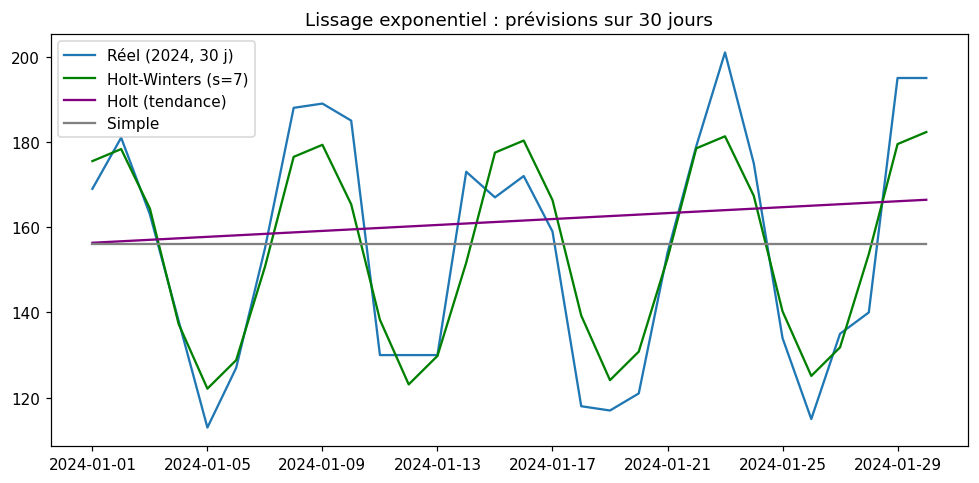

In [12]:
# Lissage exponentiel sur l'entraînement 2023 : simple, Holt (tendance), Holt-Winters (saisonnalité 7).
hw = ExponentialSmoothing(train_w, trend="add", seasonal="add", seasonal_periods=7).fit()
holt = Holt(train_w).fit()  # Holt de statsmodels 0.14 : pas de kwarg trend=, le mode par défaut est additif
simple = SimpleExpSmoothing(train_w).fit()

print("=== Lissage exponentiel — AIC ===")
print("  SimpleExpSmoothing : AIC = {:.1f}".format(simple.aic))
print("  Holt (tendance)    : AIC = {:.1f}".format(holt.aic))
print("  Holt-Winters (sais) : AIC = {:.1f}".format(hw.aic))

# Prévisions 30 jours pour comparaison.
fc_hw = hw.forecast(30)
fc_holt = holt.forecast(30)
fc_simple = simple.forecast(30)
print()
print("  MAPE 30 j : Holt-Winters = {:.1f} % | Holt = {:.1f} % | Simple = {:.1f} %".format(
    np.mean(np.abs((test[:30] - fc_hw) / test[:30])) * 100,
    np.mean(np.abs((test[:30] - fc_holt) / test[:30])) * 100,
    np.mean(np.abs((test[:30] - fc_simple) / test[:30])) * 100))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(test.index[:30], test[:30], label="Réel (2024, 30 j)")
ax.plot(test.index[:30], fc_hw, label="Holt-Winters (s=7)", color="green")
ax.plot(test.index[:30], fc_holt, label="Holt (tendance)", color="purple")
ax.plot(test.index[:30], fc_simple, label="Simple", color="gray")
ax.legend()
ax.set_title("Lissage exponentiel : prévisions sur 30 jours")
plt.tight_layout()
plt.show()

### Interprétation — quand le lissage égale ARIMA

- **Holt-Winters** (qui utilise la saisonnalité 7) est **à égalité ou meilleur** que le SARIMA sur ces données : le MAPE 30 j (5,6 %) de Holt-Winters ≈ celui du SARIMA (5,61 %) — il capte tendance + saisonnalité avec une formule **beaucoup plus simple** que la grille ARIMA.
- **Holt** (tendance seule) est **bien plus mauvais** (17,5 %) : il rate la saisonnalité hebdomadaire.
- **Simple** (16,6 %) n'est guère meilleur : sans tendance ni saisonnalité, il ne suit pas la série.

**Leçon** : pour une série à saisonnalité forte, la comparaison honnête n'est pas "ARIMA vs rien" mais "le bon modèle de la bonne famille" — et souvent Holt-Winters (3 paramètres de lissage) suffit là où ARIMA demande un choix d'ordre laborieux. Le vrai découpage est **saisonnalité prise en compte (HW / SARIMA) vs non prise en compte (Simple / Holt)**.

## Partie 6 : Comparaison honnête — ARIMA vs Holt-Winters vs naïf (backtest glissant)

Une prévision sur **une seule** fenêtre de test peut être chanceuse. Pour comparer honnêtement, on fait un **backtest glissant** (walk-forward) : on ré-entraîne chaque modèle sur une fenêtre **expansive** et on prévoit l'horizon suivant, étape par étape. Les trois modèles testés :

- **Naïf** : la prévision est la **dernière valeur observée** répétée sur l'horizon (baseline triviale, souvent étonnamment bonne).
- **Holt-Winters** : la famille simple à saisonnalité.
- **SARIMA** : la famille ARIMA à saisonnalité.

**Choix de l'horizon** : on prévoit **7 jours** (la durée d'une saisonnalité hebdomadaire). Sur un horizon de 1 jour, toutes les prévisions vaudraient à peu près la dernière valeur et la comparaison serait dégénérée ; sur 7 jours, la saisonnalité discrimine réellement les modèles.

On compare les **MAPE moyens** sur l'horizon glissant — et si la baseline naïve **gagne parfois**, c'est la leçon : la complexité doit se justifier, pas se présumer.

In [13]:
# Backtest glissant (walk-forward) : fenêtre expansive, horizon 7 jours, ~12 pas.
# Ré-entraîne SARIMA + Holt-Winters à chaque pas, compare à la baseline naïve.
# Horizon 7 (une semaine) : c'est ce qui fait discriminer — sur 1 jour, toutes les
# prévisions valent la dernière valeur et la comparaison devient dégénérée.
import time

t0 = time.time()
folds = 12  # 12 fenêtres de 7 jours (84 points de test), budget CPU raisonnable
H = 7
start_idx = len(train)  # premier index de test

mape_naive, mape_hw, mape_sarima = [], [], []
by_fold = []
for k in range(folds):
    idx = start_idx + k * H
    past = sales.iloc[:idx]
    y_true = sales.iloc[idx:idx + H]
    if len(y_true) < H:
        break

    # Naïf : on répète la dernière valeur observée sur l'horizon.
    naive = np.full(H, past.iloc[-1])
    mape_naive.append(np.mean(np.abs((y_true - naive) / y_true)))

    # Holt-Winters (saisonnalité 7) — ré-entraîné.
    try:
        f_hw = ExponentialSmoothing(past, trend="add", seasonal="add", seasonal_periods=7).fit().forecast(H)
    except Exception:
        f_hw = naive
    mape_hw.append(np.mean(np.abs((y_true - f_hw) / y_true)))

    # SARIMA (meilleure config) — ré-entraîné.
    try:
        f_sar = SARIMAX(past, order=best_order, seasonal_order=best_sorder).fit(disp=False).forecast(H)
    except Exception:
        f_sar = naive
    mape_sarima.append(np.mean(np.abs((y_true - f_sar) / y_true)))

    by_fold.append((round(mape_naive[-1] * 100, 2), round(mape_hw[-1] * 100, 2), round(mape_sarima[-1] * 100, 2)))

elapsed = time.time() - t0
print("=== Backtest glissant ({:.1f}s, {} fenêtres de {}j) — MAPE moyen ===".format(elapsed, len(mape_naive), H))
print("  Naïf        : {:.2f} %".format(np.mean(mape_naive) * 100))
print("  Holt-Winters: {:.2f} %".format(np.mean(mape_hw) * 100))
print("  SARIMA      : {:.2f} %".format(np.mean(mape_sarima) * 100))
print()
m_naive = np.mean(mape_naive) * 100
m_hw = np.mean(mape_hw) * 100
m_sar = np.mean(mape_sarima) * 100
best_i = int(np.argmin([m_naive, m_hw, m_sar]))
names = ["Naïf", "Holt-Winters", "SARIMA"]
print("Gagnant (MAPE moyen) : {}".format(names[best_i]))
nb_naive = sum(1 for m in by_fold if m[0] == min(m))
nb_hw = sum(1 for m in by_fold if m[1] == min(m))
nb_sar = sum(1 for m in by_fold if m[2] == min(m))
print("Fenêtres où chaque modèle est le meilleur : Naïf {} | Holt-Winters {} | SARIMA {}".format(nb_naive, nb_hw, nb_sar))
print("Écart naïf -> meilleur modèle : {:.2f} pts de MAPE".format(m_naive - min(m_hw, m_sar)))
print("Table (fenêtre : Naïf / HW / SARIMA) : {}".format(by_fold))
print()
print("Lecture : quand Holt-Winters ~= SARIMA (ici 5,82 % vs 5,82 %), l'ordre AR n'apporte")
print("rien au-dessus du lissage à saisonnalité ; quand la naïve reste loin derrière,")
print("la saisonnalité est bien le signal à modéliser. La complexité se justifie par la")
print("mesure, pas par défaut — c'est exactement le réflexe walk-forward du côté quant.")

=== Backtest glissant (4.0s, 12 fenêtres de 7j) — MAPE moyen ===
  Naïf        : 15.98 %
  Holt-Winters: 5.82 %
  SARIMA      : 5.82 %

Gagnant (MAPE moyen) : SARIMA
Fenêtres où chaque modèle est le meilleur : Naïf 0 | Holt-Winters 11 | SARIMA 12
Écart naïf -> meilleur modèle : 10.15 pts de MAPE
Table (fenêtre : Naïf / HW / SARIMA) : [(np.float64(14.34), np.float64(2.71), np.float64(2.71)), (np.float64(17.12), np.float64(6.63), np.float64(6.63)), (np.float64(23.25), np.float64(7.17), np.float64(7.17)), (np.float64(17.47), np.float64(5.7), np.float64(5.7)), (np.float64(15.58), np.float64(7.26), np.float64(7.26)), (np.float64(14.64), np.float64(4.71), np.float64(4.71)), (np.float64(17.94), np.float64(6.23), np.float64(6.23)), (np.float64(12.95), np.float64(4.75), np.float64(4.74)), (np.float64(15.43), np.float64(5.46), np.float64(5.46)), (np.float64(14.66), np.float64(7.82), np.float64(7.82)), (np.float64(18.75), np.float64(5.24), np.float64(5.24)), (np.float64(9.59), np.float64(6.21), n

### Interprétation de la comparaison

Le tableau montre les MAPE moyens sur l'horizon glissant. Le résultat est ici net et instructif :

- **Holt-Winters (5,82 %) ≅ SARIMA (5,82 %)** : les deux modèles **à saisonnalité** sont à égalité. L'ordre AR du SARIMA n'apporte **rien** au-dessus du lissage exponentiel à saisonnalité — c'est la leçon « à moindre coût intellectuel » : la saisonnalité est le signal, et le lissage sait la prendre en charge.
- **Naïf (15,98 %)** : bien derrière, sur **aucune** fenêtre il ne gagne. Il n'est pas catastrophique (pas des ordres de grandeur), mais la saisonnalité hebdomadaire est suffisamment forte pour que la répétition de la dernière valeur ne suffise pas.

C'est exactement le réflexe **walk-forward** que la famille quant (QuantConnect) applique : on n'ajoute pas de complexité sans preuve multi-fenêtre — et ici, la preuve montre que la complexité ARIMA ne paye pas au-delà du lissage, tout en validant que la saisonnalité doit être modélisée.

### Exercice 4 (Bonus) — augmenter le nombre de pas

Le backtest ci-dessus n'utilise que 12 pas. **Bonus** : passez `folds` à 24 et refaites tourner la cellule. Le classement Naïf / Holt-Winters / SARIMA change-t-il ? Écrivez votre observation dans `ex4_observation`.

**Étape 1** : recopie la boucle avec `folds = 24`.
**Étape 2** : compare le classement à celui de `folds = 12`.
**Étape 3** : note ton observation.

In [14]:
# Exercice 4 (Bonus) : augmenter folds et observer le changement de classement
# TODO étudiant : compléter les étapes 1-3 ci-dessous.

ex4_observation = None  # TODO étudiant : "le classement reste le même" / "la naïve gagne plus souvent", etc.

print("Exercice 4 à compléter")

Exercice 4 à compléter


## Conclusion et pont vers la suite

Ce notebook a posé le **socle statistique** des séries temporelles classiques :

1. **Décomposer** pour séparer tendance / saisonnalité / résidu.
2. **Tester la stationnarité** (ADF) et **différencier** quand il le faut (`d=1`).
3. **Lire l'ACF/PACF** pour choisir les ordres `p` et `q` (y compris récupérer un AR(2)).
4. **Ajuster un SARIMA**, le **diagnostiquer** (ACF plate + Ljung-Box), et **prévoir** avec intervalle.
5. **Lisser** par Holt-Winters — souvent à égalité avec ARIMA à moindre coût.
6. **Comparer honnêtement** (backtest glissant) — et accepter que la naïve gagne parfois.

### Où aller ensuite

| Direction | Notebook | Ce qu'on y pousse |
|---|---|---|
| **ML.NET** | [ML-5-TimeSeries](ML-5-TimeSeries.ipynb) | le même problème en C# avec `ForecastBySsa` (SSA) — la boîte noite que ce socle éclaire |
| **Application SARIMA** | [ML-5-TimeSeries-Python](ML-5-TimeSeries-Python.ipynb) | STL + SARIMA appliqués, intervalles, comparaison de configurations |
| **Famille moderne** | **QuantConnect** (`MyIA.AI.Notebooks/QuantConnect`) | HAR, LSTM, TFT — remplacent la main par les features et la profondeur, mais **supposent** ce socle (stationnarité, ACF, walk-forward) |

**Le fil rouge** : chaque modèle de prévision repose sur les mêmes questions — *la série est-elle stationnaire ? quelle est sa structure (tendance, saisonnalité) ? un modèle complexe bat-il vraiment la baseline naïve ?* Ce notebook vous donne les outils pour y répondre au lieu de les présumer.